# Taller: Regresión Logística Multiclase

### Aprendizaje Supervisado — Clasificación con 3 clases

**Pontificia Universidad Católica del Ecuador**  
*Carrera de Ingeniería de Sistemas de Información*  

**Asignatura:** Inteligencia Artificial · Sexto Semestre  

---  

**Cómo usar este material:**  
Este taller se entrega como página de referencia (HTML).  
Reproduce cada celda de código en tu propio Google Colab o Jupyter Notebook, en el mismo orden en que aparecen — cada bloque depende de los objetos creados en el anterior.  
No necesitas este archivo para trabajar; solo tu propio notebook y el archivo `triaje_ecuador.csv`.

## Objetivos del taller

Al finalizar este taller el estudiante será capaz de:

* **Explorar visualmente** un dataset con 3 clases desbalanceadas.
* **Construir un pipeline** de preprocesamiento con `ColumnTransformer` para clasificación multiclase.
* **Entrenar y comparar** un modelo *OvR* (`OneVsRestClassifier`) y uno *Softmax* (`LogisticRegression`, comportamiento por defecto) con scikit-learn.
* **Interpretar la matriz de confusión** multiclase y distinguir errores críticos de errores leves.
* **Elegir entre `macro avg` y `weighted avg`** según el contexto del problema.
* **Usar `predict_proba`** para analizar la seguridad del modelo en casos individuales.
* **Reentrenar el modelo final** con el 100% de los datos, exportarlo con `joblib` y usarlo con datos nuevos.

## Dataset

**Archivo:** `triaje_ecuador.csv` — 1800 registros de pacientes en urgencias hospitalarias (dataset sintético).

| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **edad** | Numérica | Edad del paciente en años |
| **frecuencia_cardiaca** | Numérica | Latidos por minuto |
| **presion_sistolica** | Numérica | Presión arterial sistólica (mmHg) |
| **temperatura** | Numérica | Temperatura corporal en °C |
| **saturacion_o2** | Numérica | Saturación de oxígeno (%) |
| **sexo** | Categórica | M / F |
| **provincia** | Categórica | Provincia de residencia (10 provincias) |
| **motivo_consulta** | Categórica | Dolor / Trauma / Respiratorio / Otro |
| **riesgo** | **Objetivo (y)** | Bajo / Medio / Alto |

## Estructura del taller

| Bloque | Tipo | Contenido |
| :--- | :---: | :--- |
| **A1** | Guiado | Carga y exploración visual |
| **A2** | Guiado | Preprocesamiento con `ColumnTransformer` |
| **A3** | Guiado | Entrenamiento — OvR vs Softmax |
| **A4** | Guiado | Matriz de confusión multiclase |
| **A5** | Guiado | Métricas: macro avg vs weighted avg |
| **A6** | Guiado | `predict_proba` + caso individual |
| **B1** | Autónomo | Modelo solo con variables numéricas |
| **B2** | Autónomo | Predicción de un segundo caso individual |
| **C** | Guiado | Entrenamiento final, exportación y uso en producción |

**Instrucción:** Reproduce cada bloque de código en tu propio Colab/Jupyter, en orden. No saltes bloques — cada uno depende de objetos creados en los anteriores.

# Parte A — Laboratorio Guiado

## Bloque A1 · Carga y exploración visual

Librerías que usamos:
* `pandas` — carga y manipulación de datos.
* `matplotlib.pyplot` — gráficos.

**¿Qué observamos aquí?**  
El dataset tiene 3 clases con distribución muy desbalanceada: Riesgo Alto es minoritario.  
Esto tiene una consecuencia directa: un modelo que siempre prediga "Bajo" tendría un Accuracy ≈ 66% aunque sea completamente inútil. Por eso en este taller priorizamos `macro avg` y `weighted avg`.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('triaje_ecuador.csv')
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print()
df.info()


Filas: 1800 | Columnas: 9

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   edad                 1800 non-null   int64  
 1   sexo                 1800 non-null   object 
 2   provincia            1800 non-null   object 
 3   motivo_consulta      1800 non-null   object 
 4   frecuencia_cardiaca  1800 non-null   int64  
 5   presion_sistolica    1800 non-null   int64  
 6   temperatura          1800 non-null   float64
 7   saturacion_o2        1800 non-null   float64
 8   riesgo               1800 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 126.7+ KB


In [29]:
df.head()


,edad,sexo,provincia,motivo_consulta,frecuencia_cardiaca,presion_sistolica,temperatura,saturacion_o2,riesgo
0,56,F,Pichincha,Respiratorio,81,102,35.0,97.4,Medio
1,19,M,Pichincha,Dolor,85,106,36.8,95.9,Bajo
2,76,M,Pichincha,Dolor,131,113,37.7,96.0,Medio
3,65,M,Esmeraldas,Dolor,71,110,36.1,99.7,Bajo
4,25,M,Guayas,Respiratorio,113,122,37.2,96.3,Medio


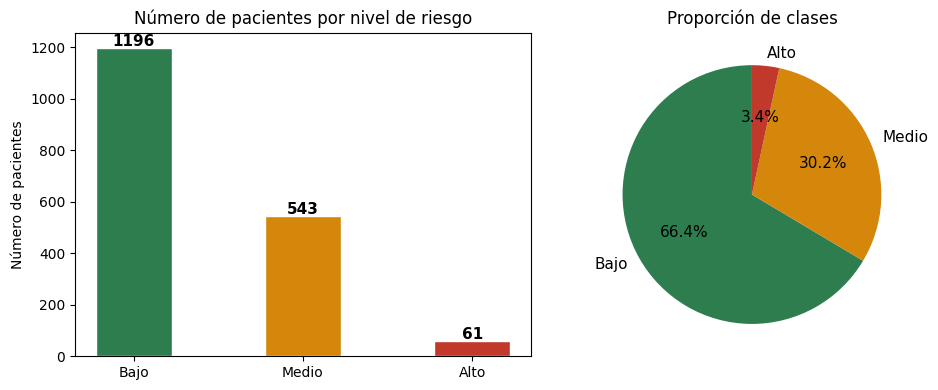

In [30]:
# Distribución de las 3 clases
orden = ['Bajo', 'Medio', 'Alto']
colores = ['#2E7D4F', '#D4870A', '#C0392B']
conteo = df['riesgo'].value_counts().reindex(orden)
pct = df['riesgo'].value_counts(normalize=True).reindex(orden) * 100
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bars = axes[0].bar(orden, conteo.values, color=colores, edgecolor='white', width=0.45)
axes[0].set_title('Número de pacientes por nivel de riesgo', fontsize=12)
axes[0].set_ylabel('Número de pacientes')
for bar, v in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 8,
                 str(v), ha='center', fontsize=11, fontweight='bold')
axes[1].pie(pct.values, labels=orden, autopct='%1.1f%%',
            colors=colores, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporción de clases', fontsize=12)
plt.tight_layout()
plt.show()


In [31]:
# Tasa de cada clase por motivo de consulta
print("Distribución de riesgo por motivo de consulta:")
print(pd.crosstab(df['motivo_consulta'], df['riesgo'], normalize='index').round(2))


Distribución de riesgo por motivo de consulta:
riesgo           Alto  Bajo  Medio
motivo_consulta                   
Dolor            0.03  0.70   0.27
Otro             0.01  0.76   0.22
Respiratorio     0.05  0.62   0.33
Trauma           0.04  0.61   0.35


## Bloque A2 · Preprocesamiento con `ColumnTransformer`

Librerías que usamos:
* `sklearn.model_selection.train_test_split`
* `sklearn.compose.ColumnTransformer`
* `sklearn.preprocessing.OneHotEncoder`, `StandardScaler`

**Diferencia clave respecto al caso binario:**  
La variable objetivo `y` contiene texto ('Bajo', 'Medio', 'Alto'). scikit-learn la acepta directamente — no necesita One-Hot Encoding (OHE). Solo se aplica OHE a las variables categóricas de `X`, igual que antes.

**¿Por qué `ColumnTransformer` y no `pd.get_dummies`?**  
`pd.get_dummies` genera columnas dummy distintas según qué categorías aparezcan en los datos que le pasas. Si luego lo usas por separado sobre una sola fila nueva (un paciente nuevo), esa fila no va a tener todas las categorías del dataset original, y las columnas faltantes quedan en 0 sin ningún error ni aviso — el modelo predice con información incompleta sin que te enteres.  

`ColumnTransformer` (dentro de un `Pipeline`, ver A3) evita este problema: aprende las categorías una sola vez con `.fit()` sobre `X_train`, y luego aplica exactamente esa misma transformación a cualquier dato nuevo con `.transform()`, con `handle_unknown='ignore'` como red de seguridad ante una categoría nunca vista.

`stratify=y` en el split garantiza que la proporción de clases se mantenga en train y test. Es especialmente importante cuando hay clases muy minoritarias como Riesgo Alto.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# 1. Separar X e y
X = df.drop('riesgo', axis=1)
y = df['riesgo']
print("Clases en y:", y.unique())


Clases en y: ['Medio' 'Bajo' 'Alto']


In [33]:
# 2. División train/test — stratify=y preserva la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")
print()
print("Clases en train:")
print(y_train.value_counts())
print()
print("Clases en test:")
print(y_test.value_counts())


Entrenamiento: 1440 filas
Prueba: 360 filas

Clases en train:
riesgo
Bajo     957
Medio    434
Alto      49
Name: count, dtype: int64

Clases en test:
riesgo
Bajo     239
Medio    109
Alto      12
Name: count, dtype: int64


In [34]:
# 3. ColumnTransformer: OHE a las categóricas + StandardScaler a las numéricas, en un solo objeto
cat_cols = ['sexo', 'motivo_consulta', 'provincia']
num_cols = ['edad', 'frecuencia_cardiaca', 'presion_sistolica', 'temperatura', 'saturacion_o2']
preproc = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols),
])
print("preproc listo. Se ajustará dentro del Pipeline en el Bloque A3.")


preproc listo. Se ajustará dentro del Pipeline en el Bloque A3.


## Bloque A3 · Entrenamiento — OvR vs Softmax

Librerías que usamos:
* `sklearn.linear_model.LogisticRegression`
* `sklearn.multiclass.OneVsRestClassifier`
* `sklearn.pipeline.Pipeline`

**¿Por qué dos estrategias?**  
La regresión logística binaria solo produce una probabilidad (sigmoide). Con 3 o más clases no hay una única clase "positiva", así que existen dos formas de extenderla — ambas construidas sobre `LogisticRegression()`:

* ⚠ **Importante:** El parámetro `multi_class` ('ovr'/'multinomial') fue eliminado de `LogisticRegression()` en scikit-learn 1.7 (deprecado desde 1.5). Con la versión actual, `LogisticRegression()` sin ningún parámetro extra ya entrena en modo **Softmax** (multinomial) cuando `y` tiene 3 o más clases — es su comportamiento nativo.
* Para **OvR** se envuelve con `OneVsRestClassifier(LogisticRegression(...))`: no es un modelo distinto, es un meta-estimador que reutiliza `LogisticRegression()` entrenándolo K veces (una por clase).

Entrenamos dos pipelines completos (preprocesamiento + modelo) sobre los mismos datos para compararlos.  
`pipeline.classes_` no es un parámetro que se configure — es un atributo que solo existe después de `.fit()`, y guarda el orden alfabético en que el modelo indexó las clases. Es importante conocerlo para interpretar correctamente `predict_proba` en A6: la columna *i* de esa salida corresponde siempre a `classes_[i]`.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
# Pipeline OvR
pipeline_ovr = Pipeline([
    ('preproc', preproc),
    ('modelo', OneVsRestClassifier(
        LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))),
])
# Pipeline Softmax (comportamiento por defecto de LogisticRegression con 3+ clases)
pipeline_soft = Pipeline([
    ('preproc', preproc),
    ('modelo', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
])
pipeline_ovr.fit(X_train, y_train)
pipeline_soft.fit(X_train, y_train)
print("Pipelines entrenados.")
print("Orden de clases:", pipeline_soft.classes_)


Pipelines entrenados.
Orden de clases: ['Alto' 'Bajo' 'Medio']


In [36]:
from sklearn.metrics import accuracy_score
y_pred_ovr = pipeline_ovr.predict(X_test)
y_pred_soft = pipeline_soft.predict(X_test)
print(f"Accuracy OvR:     {accuracy_score(y_test, y_pred_ovr):.3f}")
print(f"Accuracy Softmax: {accuracy_score(y_test, y_pred_soft):.3f}")
print()
print("Nota: el Accuracy parece alto por el desbalance de clases.")
print("En A5 veremos las métricas reales por clase.")


Accuracy OvR:     0.739
Accuracy Softmax: 0.742

Nota: el Accuracy parece alto por el desbalance de clases.
En A5 veremos las métricas reales por clase.


## Bloque A4 · Matriz de confusión multiclase

Librerías que usamos:
* `sklearn.metrics.confusion_matrix`
* `sklearn.metrics.ConfusionMatrixDisplay`

En la matriz multiclase:
* Los valores en la diagonal son predicciones correctas.
* Los valores fuera de la diagonal son errores.

No todos los errores son iguales. Clasificar un paciente de Riesgo Alto como Bajo es mucho más grave que clasificar uno de Riesgo Bajo como Medio. La matriz nos permite identificar exactamente dónde se concentran los errores críticos.

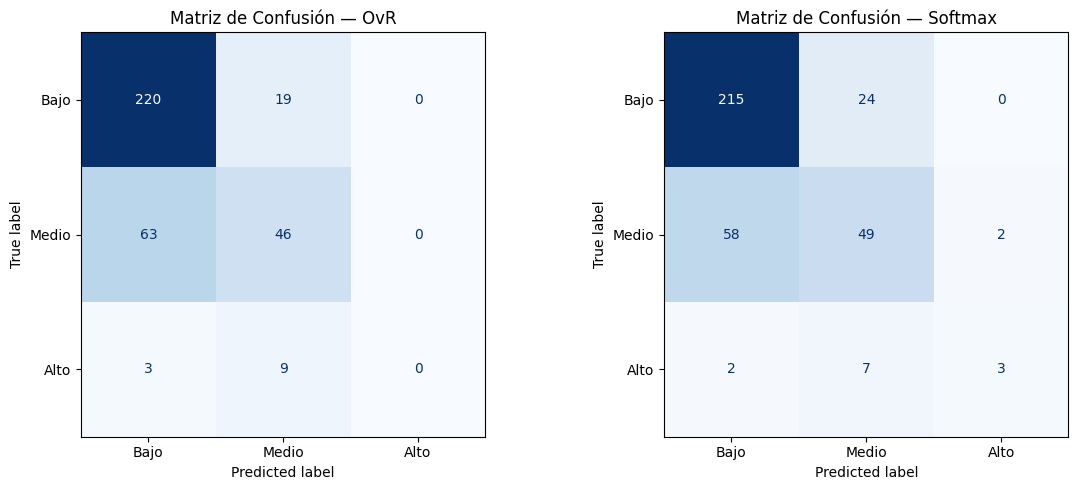

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, titulo in zip(axes, [y_pred_ovr, y_pred_soft], ['OvR', 'Softmax']):
    cm = confusion_matrix(y_test, y_pred, labels=['Bajo', 'Medio', 'Alto'])
    ConfusionMatrixDisplay(cm, display_labels=['Bajo', 'Medio', 'Alto']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión — {titulo}', fontsize=12)
plt.tight_layout()
plt.show()


In [38]:
# Lectura de errores clave del modelo Softmax
cm = confusion_matrix(y_test, y_pred_soft, labels=['Bajo', 'Medio', 'Alto'])
print("Predicciones correctas (diagonal):")
print(f"  Riesgo Bajo  -> {cm[0, 0]}")
print(f"  Riesgo Medio -> {cm[1, 1]}")
print(f"  Riesgo Alto  -> {cm[2, 2]}")
print()
print("Errores críticos:")
print(f"  Riesgo Alto clasificado como Medio: {cm[2, 1]}")
print(f"  Riesgo Alto clasificado como Bajo:  {cm[2, 0]}  <- el más grave")


Predicciones correctas (diagonal):
  Riesgo Bajo  -> 215
  Riesgo Medio -> 49
  Riesgo Alto  -> 3

Errores críticos:
  Riesgo Alto clasificado como Medio: 7
  Riesgo Alto clasificado como Bajo:  2  <- el más grave


## Bloque A5 · Métricas: macro avg vs weighted avg

Librerías que usamos:
* `sklearn.metrics.classification_report`
* `sklearn.metrics.f1_score`

**¿Qué métrica usar?**
* **`macro avg`** — promedio simple entre clases. Penaliza igual un error en Riesgo Alto (61 casos, 3.4% del total) que en Riesgo Bajo (1196 casos). Úsalo cuando todas las clases tienen igual importancia clínica.
* **`weighted avg`** — promedio ponderado por el número de casos. Las clases mayoritarias pesan más. Úsalo cuando quieres reflejar el rendimiento global considerando el volumen.

En triaje hospitalario el `macro avg` es más relevante: detectar un Riesgo Alto es tan crítico como detectar un Riesgo Bajo, aunque haya muchos menos casos de Alto.

In [39]:
from sklearn.metrics import classification_report
print("=== Pipeline OvR ===")
print(classification_report(y_test, y_pred_ovr,
                             labels=['Bajo', 'Medio', 'Alto'], digits=3))


=== Pipeline OvR ===
              precision    recall  f1-score   support

        Bajo      0.769     0.921     0.838       239
       Medio      0.622     0.422     0.503       109
        Alto      0.000     0.000     0.000        12

    accuracy                          0.739       360
   macro avg      0.464     0.448     0.447       360
weighted avg      0.699     0.739     0.709       360



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
print("=== Pipeline Softmax ===")
print(classification_report(y_test, y_pred_soft,
                             labels=['Bajo', 'Medio', 'Alto'], digits=3))


=== Pipeline Softmax ===
              precision    recall  f1-score   support

        Bajo      0.782     0.900     0.837       239
       Medio      0.613     0.450     0.519       109
        Alto      0.600     0.250     0.353        12

    accuracy                          0.742       360
   macro avg      0.665     0.533     0.569       360
weighted avg      0.724     0.742     0.724       360



In [41]:
from sklearn.metrics import f1_score
f1_ovr_macro = f1_score(y_test, y_pred_ovr, average='macro')
f1_soft_macro = f1_score(y_test, y_pred_soft, average='macro')
f1_ovr_weighted = f1_score(y_test, y_pred_ovr, average='weighted')
f1_soft_weighted = f1_score(y_test, y_pred_soft, average='weighted')
print(f"F1 macro    — OvR: {f1_ovr_macro:.3f}   Softmax: {f1_soft_macro:.3f}")
print(f"F1 weighted — OvR: {f1_ovr_weighted:.3f}   Softmax: {f1_soft_weighted:.3f}")
print()
print("Fíjate en el recall de la clase Alto en ambos reportes: es la métrica que más")
print("cambia entre OvR y Softmax, y la más importante clínicamente en este dataset.")


F1 macro    — OvR: 0.447   Softmax: 0.569
F1 weighted — OvR: 0.709   Softmax: 0.724

Fíjate en el recall de la clase Alto en ambos reportes: es la métrica que más
cambia entre OvR y Softmax, y la más importante clínicamente en este dataset.


## Bloque A6 · `predict_proba` multiclase + caso individual

**¿Qué cambia en `predict_proba` para multiclase?**  
En clasificación binaria devolvía 2 columnas. En multiclase devuelve **K columnas**, una por clase, en el orden de `pipeline.classes_`. Las probabilidades de cada fila siempre suman exactamente 1.0.  
Esto permite conocer no solo la clase predicha sino también qué tan seguro está el modelo. Si las probabilidades están muy cerca entre sí, el caso debe revisarse manualmente.

**Datos del caso individual:**

| Variable | Valor |
| :--- | :--- |
| **Edad** | 24 años |
| **Sexo** | M |
| **Provincia** | Pichincha |
| **Motivo de consulta** | Respiratorio |
| **Frecuencia cardíaca** | 118 lpm |
| **Presión sistólica** | 98 mmHg |
| **Temperatura** | 37.2 °C |
| **Saturación O₂** | 88.0% |

Este paciente es joven pero tiene saturación O₂ crítica (normal ≥ 95%) y taquicardia leve.

In [42]:
# Primeras 5 predicciones con probabilidades (test set)
y_proba_soft = pipeline_soft.predict_proba(X_test)
clases = pipeline_soft.classes_
print("Clases en orden:", clases)
print()
for i in range(5):
    p = y_proba_soft[i]
    pred = clases[p.argmax()]
    real = y_test.iloc[i]
    ok = "OK" if pred == real else "X"
    probs = "  ".join(f"P({c})={v:.3f}" for c, v in zip(clases, p))
    print(f"[{i}] {probs}  -> predicho={pred:<6} real={real:<6} {ok}")


Clases en orden: ['Alto' 'Bajo' 'Medio']

[0] P(Alto)=0.003  P(Bajo)=0.860  P(Medio)=0.137  -> predicho=Bajo   real=Medio  X
[1] P(Alto)=0.001  P(Bajo)=0.799  P(Medio)=0.200  -> predicho=Bajo   real=Bajo   OK
[2] P(Alto)=0.032  P(Bajo)=0.558  P(Medio)=0.410  -> predicho=Bajo   real=Bajo   OK
[3] P(Alto)=0.003  P(Bajo)=0.855  P(Medio)=0.142  -> predicho=Bajo   real=Bajo   OK
[4] P(Alto)=0.057  P(Bajo)=0.219  P(Medio)=0.725  -> predicho=Medio  real=Bajo   X


In [43]:
# Caso individual: gracias al Pipeline, ya NO hace falta hacer OHE ni reindex a mano.
# El pipeline recuerda exactamente qué transformación aplicar — el mismo código
# que usarías aquí es el que se usa en producción (ver Bloque C).
paciente = pd.DataFrame({
    'edad': [24],
    'sexo': ['M'],
    'provincia': ['Pichincha'],
    'motivo_consulta': ['Respiratorio'],
    'frecuencia_cardiaca': [118],
    'presion_sistolica': [98],
    'temperatura': [37.2],
    'saturacion_o2': [88.0]
})
clase_pred = pipeline_soft.predict(paciente)
proba_pred = pipeline_soft.predict_proba(paciente)
print(f"Clase predicha: {clase_pred[0]}")
print()
for clase, prob in zip(pipeline_soft.classes_, proba_pred[0]):
    print(f"  P({clase}): {prob:.3f}")
print()
print("Interpretación:")
print("  Saturación O2 = 88% -> valor crítico (normal >= 95%)")
print("  A pesar de tener 24 años, los signos vitales determinan el riesgo.")


Clase predicha: Medio

  P(Alto): 0.073
  P(Bajo): 0.059
  P(Medio): 0.868

Interpretación:
  Saturación O2 = 88% -> valor crítico (normal >= 95%)
  A pesar de tener 24 años, los signos vitales determinan el riesgo.


# Parte B — Práctica Autónoma

Usa los mismos pasos aprendidos en la Parte A. Completa los `# TODO` y responde las preguntas en las celdas de Markdown.

## Bloque B1 · Modelo solo con variables numéricas

**Contexto:**  
En A3 entrenaste el modelo con todas las variables, incluidas las categóricas transformadas con OHE.  
¿Qué pasa si usamos solo las 5 variables numéricas (signos vitales y edad)? ¿Son suficientes para predecir el riesgo sin información categórica?

**Tu tarea:**
1. Crea `X2` seleccionando solo las columnas numéricas del DataFrame `df` original.
2. Constuye un pipeline con `StandardScaler` + `LogisticRegression` (Softmax).
3. Evalúa con `classification_report` y matriz de confusión.
4. Compara con el modelo completo de A5 y responde las preguntas.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# TODO 1: Seleccionar solo variables numéricas
cols_numericas = ['edad', 'frecuencia_cardiaca', 'presion_sistolica', 'temperatura', 'saturacion_o2']
X2 = df[cols_numericas]
y2 = df['riesgo']


In [45]:
# TODO 2: División train/test con stratify=y2
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)


In [46]:
# TODO 3: Construir el pipeline (StandardScaler + LogisticRegression Softmax)
pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
])
# TODO 4: Entrenar
pipeline2.fit(X2_train, y2_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

In [47]:
# TODO 5: Predecir y mostrar classification_report
y2_pred = pipeline2.predict(X2_test)
print(classification_report(y2_test, y2_pred, labels=['Bajo', 'Medio', 'Alto'], digits=3))


              precision    recall  f1-score   support

        Bajo      0.790     0.883     0.834       239
       Medio      0.618     0.505     0.556       109
        Alto      1.000     0.333     0.500        12

    accuracy                          0.750       360
   macro avg      0.803     0.574     0.630       360
weighted avg      0.745     0.750     0.739       360



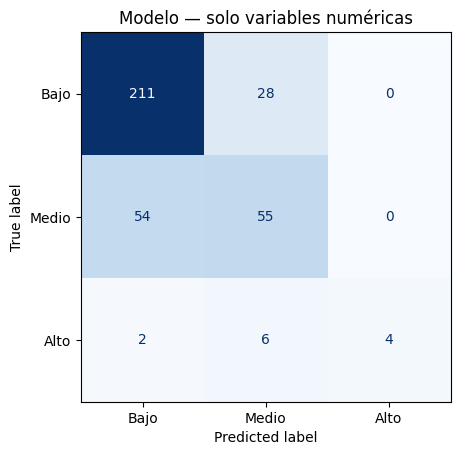

In [48]:
# TODO 6: Mostrar matriz de confusión
cm2 = confusion_matrix(y2_test, y2_pred, labels=['Bajo', 'Medio', 'Alto'])
ConfusionMatrixDisplay(cm2, display_labels=['Bajo', 'Medio', 'Alto']).plot(
    cmap='Blues', colorbar=False)
plt.title('Modelo — solo variables numéricas')
plt.show()

Completa la tabla con tus resultados:

| Métrica | Modelo completo (A5) | Modelo numérico (B1) | Diferencia |
| :--- | :---: | :---: | :---: |
| **Macro F1** | 0.569 | 0.630 | +0.061 |
| **Weighted F1** | 0.724 | 0.739 | +0.015 |
| **Recall (Alto)** | 0.250 | 0.333 | +0.083 |

**Preguntas:**
1. **¿El modelo con solo variables numéricas es peor, igual o mejor que el completo?**  
   Es ligeramente mejor en las métricas generales y muestra una mejoría notable en la clase minotaria que representa a Alto, ya que paso de 0.250 a 0.333.
2. **¿Tiene sentido clínicamente que los signos vitales sean más informativos que la provincia o el motivo de consulta?**  
   Sí, clínicamente los parámetros fisiológicos objetivos como la saturación o el ritmo cardíaco determinan de manera más directa el riesgo de un paciente que las variables demográficas o administrativas.
3. **¿Qué variable eliminarías del modelo completo si quisieras simplificarlo sin perder mucho rendimiento?**  
   Podríamos eliminar la variable `provincia` y `sexo`, ya que suelen aportar poco peso clínico en la determinación del estado de urgencia.

## Bloque B2 · Predicción de un segundo caso individual

**Contexto:**  
Aplica el pipeline Softmax original (entrenado en A3) para evaluar a un nuevo paciente. Sigue exactamente los mismos pasos del Bloque A6 — con el `Pipeline` ya no hace falta repetir OHE ni escalado a mano.

**Datos del nuevo paciente:**

| Variable | Valor |
| :--- | :--- |
| **Edad** | 67 años |
| **Sexo** | F |
| **Provincia** | Guayas |
| **Motivo de consulta** | Dolor |
| **Frecuencia cardíaca** | 74 lpm |
| **Presión sistólica** | 135 mmHg |
| **Temperatura** | 36.9 °C |
| **Saturación O₂** | 97.0% |

**Tu tarea:**
1. Construye el DataFrame del paciente.
2. Predice clase y probabilidades con `pipeline_soft.predict()` y `pipeline_soft.predict_proba()`.
3. Responde las preguntas.

In [49]:
# TODO 1: Crear el DataFrame del paciente (completa con los datos de la tabla de arriba)
paciente2 = pd.DataFrame({
    'edad': [67], 'sexo': ['F'], 'provincia': ['Guayas'], 'motivo_consulta': ['Dolor'],
    'frecuencia_cardiaca': [74], 'presion_sistolica': [135],
    'temperatura': [36.9], 'saturacion_o2': [97]
})
# TODO 2: Predecir clase y probabilidades directamente con el pipeline
clase2 = pipeline_soft.predict(paciente2)
proba2 = pipeline_soft.predict_proba(paciente2)
# TODO 3: Mostrar resultado
print(f"Clase predicha: {clase2[0]}")
for clase, prob in zip(pipeline_soft.classes_, proba2[0]):
     print(f"  P({clase}): {prob:.3f}")


Clase predicha: Bajo
  P(Alto): 0.003
  P(Bajo): 0.787
  P(Medio): 0.211


**Responde:**

1. **¿Cuál es la clase predicha y con qué probabilidad?**  
   La clase predicha es Bajo con una probabilidad del 78.7%.

2. **Compara este paciente (67 años, sat O₂ = 97%) con el del Bloque A6 (24 años, sat O₂ = 88%). ¿Cuál tiene mayor probabilidad de Riesgo Alto? ¿Por qué?**  
   El paciente del Bloque A6 tiene una probabilidad de Riesgo Alto significativamente mayor de 7.3% vs 0.3%. Esto se debe a que la saturación de oxígeno del primer paciente es del 88%, un valor crítico respiratorio, mientras que el segundo paciente está estable.

3. **¿La edad de 67 años influyó en la predicción? ¿Cómo lo sabes?**  
   Sí influyó, pero no fue suficiente para categorizarlo como alto riesgo. Se observa que la probabilidad de Riesgo Medio es del 21.1%, en parte asociada a la edad avanzada y presión ligeramente elevada, pero con signos estables por lo que predomina el riesgo Bajo.

4. **Si el modelo predice Riesgo Bajo con P(Bajo) = 0.52 y P(Medio) = 0.41, ¿lo darías de alta sin revisión adicional? Justifica.**  
   No, porque hay una incertidumbre muy alta y la diferencia de probabilidad es muy estrecha. Ante casos donde el modelo no muestra una certeza clara, siempre se requiere la evaluación clínica presencial y revisión del triage de forma manual.

# Bloque C — Entrenamiento Final, Exportación y Uso en Producción

Una vez comparados OvR y Softmax (A3–A5) y elegida la estrategia (Softmax, por el mejor recall en la clase Alto), el último paso es preparar el modelo para uso real, fuera de este notebook.

**Idea central:**  
El train/test split (80/20) sirvió para **medir** qué tan bien generaliza el modelo — eso ya se hizo en los bloques anteriores. Una vez validado ese resultado, el modelo que se usa en producción **se reentrena con el 100% de los datos disponibles**, porque ya no necesitamos reservar una porción para medir: mientras más datos vea el modelo final, mejor.

## C.1 · Reentrenar con el 100% de los datos

* **Modelo de evaluación (80%)** — El `pipeline_soft` de A3: se entrenó solo con `X_train`, su único propósito fue medir precision/recall/F1 por clase.
* **Pipeline final (100%)** — Se reentrena con el dataset completo (`X`, `y`). Es el que se exporta y se usa con pacientes nuevos.

In [50]:
pipeline_final = Pipeline([
    ('preproc', preproc),
    ('modelo', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
])
pipeline_final.fit(X, y)   # X, y completos — no X_train
print("pipeline_final entrenado con el 100% de los datos (n =", len(X), ").")


pipeline_final entrenado con el 100% de los datos (n = 1800 ).


## C.2 · Exportar el pipeline con `joblib`

`joblib` guarda objetos de Python (como un pipeline ya entrenado) en un archivo `.pkl`. Al exportar `pipeline_final` se guardan `preproc` y `modelo` juntos, como un solo objeto: nunca pueden desincronizarse ni cargarse en el orden equivocado, a diferencia de guardar el scaler y el modelo por separado.

In [51]:
import joblib
joblib.dump(pipeline_final, 'modelo_triaje.pkl')
print("Modelo exportado a modelo_triaje.pkl")


Modelo exportado a modelo_triaje.pkl


## C.3 · Usar el modelo con datos nuevos

Así se usa el archivo exportado **desde otro programa, sin este notebook**: solo se necesita el archivo `.pkl` y `pandas` / `scikit-learn` / `joblib` instalados.

In [52]:
import joblib
import pandas as pd
pipeline_prod = joblib.load('modelo_triaje.pkl')
paciente_nuevo = pd.DataFrame({
    'edad': [24], 'sexo': ['M'],
    'provincia': ['Pichincha'],
    'motivo_consulta': ['Respiratorio'],
    'frecuencia_cardiaca': [118],
    'presion_sistolica': [98],
    'temperatura': [37.2],
    'saturacion_o2': [88.0]
})
pred = pipeline_prod.predict(paciente_nuevo)
proba = pipeline_prod.predict_proba(paciente_nuevo)
print(f"Clase predicha: {pred[0]}")
for clase, p in zip(pipeline_prod.classes_, proba[0]):
    print(f"  P({clase}): {p:.3f}")


Clase predicha: Medio
  P(Alto): 0.135
  P(Bajo): 0.055
  P(Medio): 0.811


Por qué esto es tan simple:
- `pipeline_prod` ya incluye el preprocesamiento: `predict()` y `predict_proba()` aplican `preproc` por dentro, con las mismas categorías y el mismo escalado que se aprendieron en el entrenamiento.
- Sigue funcionando con pacientes nuevos gracias a `handle_unknown='ignore'`: si aparece una provincia o motivo de consulta que nunca estuvo en los datos de entrenamiento, el pipeline no falla.
- Esto es exactamente lo que evita el bug de `pd.get_dummies` + reindex manual: aquí no hay ningún paso adicional que se nos pueda olvidar.

Cierre del taller: ya completaste el flujo completo de un proyecto de clasificación multiclase — desde la exploración de datos hasta un modelo listo para producción.